# Odšumění zašuměného signálu procesního senzoru pomocí PROC LOESS

## Shrnutí

Snímač teploty v peci na výrobní lince je vzorkován jednou za sekundu během startu, takže každé měření mísí pomalý nelineární tepelný přechod (rychlá náběhová rampa, ustalující se překmit a poté návrat k žádané hodnotě 300 °C) s výrazným měřicím šumem. Tento sešit používá **PROC LOESS** k neparametrickému obnovení podkladového signálu. U 100vzorkového záznamu kritérium AICC zvolilo vyhlazovací parametr 0,08 (8 ekvivalentních parametrů); výsledná křivka věrně sleduje latentní signál a zanechává rezidua se směrodatnou odchylkou 3,10 °C — v podstatě 4 °C šumu, který jsme vnesli, minus rozptyl, který model vysvětlí. Oproti známé skutečné hodnotě odhad LOESS snižuje střední kvadratickou chybu ze 14,77 (surová data) na 6,63 a krok SCORE převzorkuje odšuměný signál na rovnoměrnou monitorovací mřížku pro navazující statistické řízení procesu.

## Zdroje dat

| Datová sada | Řádky | Proměnné | Popis |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (uplynulé sekundy, 0–99), `temp` (naměřená teplota v peci, °C), `truth` (latentní bezšumový signál, pouze pro validaci) | Syntetický záznam senzoru v peci, jeden vzorek za sekundu. Latentní signál je rychlá náběhová rampa směrem k žádané hodnotě 300 °C s tlumeným překmitem, který vrcholí kolem t = 28 (~295 °C), poklesne a ustálí se zpět k žádané hodnotě; naměřená `temp` přidává Gaussův měřicí šum (sm. odch. ~4 °C). |
| `grid` | 60 | `t` (rovnoměrná monitorovací mřížka 0–99) | Pravidelná časová mřížka použitá příkazem SCORE k vygenerování rovnoměrně rozloženého odšuměného signálu pro tvorbu SPC grafu. |

V provozu výrobní linky zaznamenává snímač teploty v peci teplotu jednou za sekundu během startu. Zaznamenaná hodnota je **skutečný tepelný stav plus měřicí šum**. Skutečný stav se neřídí žádným čistým parametrickým vzorcem — během náběhu stoupá, překmitne žádanou hodnotu a poté se ustálí — takže by globální lineární nebo polynomiální model byl špatný.

**Lokální regrese (LOESS)** je správný nástroj: přizpůsobuje polynomy nízkého stupně posuvným lokálním okolím, čímž obnovuje libovolně tvarovaný hladký signál, aniž bychom museli specifikovat jeho funkční tvar. Zde postupujeme takto:

1. Simulujeme realistický zašuměný 100vzorkový záznam senzoru.
2. Necháme `PROC LOESS`, aby si sama zvolila vyhlazovací šířku pásma pomocí kritéria AICC.
3. Připojíme k vyhlazenému signálu 95% interval spolehlivosti.
4. Ohodnotíme model na pravidelné mřížce pro navazující SPC.
5. Kvantifikujeme, kolik šumu jsme odstranili.

## Krok 1 — Simulace záznamu senzoru

Generujeme 100 vzorků v rozmezí 0–99 sekund. Latentní signál `truth` je rychlá náběhová rampa směrem k žádané hodnotě 300 °C s tlumeným překmitem — tvar, který žádná přímka ani jediný polynom dobře nezachytí: prudce stoupá, vrcholí nad žádanou hodnotou kolem t = 28, poklesne a poté se ustálí zpět. Naměřená `temp` přidává Gaussův měřicí šum. `call streaminit` fixuje počáteční hodnotu generátoru, takže je běh reprodukovatelný.

In [1]:
data sensor;
    CALL streaminit(70421);
    setpoint = 300;
    OPAKUJ t = 0 TO 99;
        /* Latentní signál: rychlá náběhová rampa + tlumený ustalující se překmit */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Naměřená hodnota = skutečná hodnota + měřicí šum (sm. odch. ~4 °C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        VÝSTUP;
    KONEC;
    PONECHAT t TEMP truth;
    ŠTÍTEK t="Čas (s)" TEMP="Teplota (°C)" truth="Skutečná hodnota (°C)";
SPUSTIT;

PROCEDURA TISK data=sensor(obs=8) noobs ŠTÍTEK;
    NÁZEV 'Prvních 8 vzorků senzoru';
SPUSTIT;

                                                Prvních 8 vzorků senzoru                                                

 Čas (s)    Teplota (°C)     Skutečná hodnota (°C)
       0    0.1684867131                         0
       1   28.1933107495             32.0778466448
       2   61.6123615699             61.2117857105
       3   85.5053781561              87.643846097
       4  110.5560474248            111.5945193774
       5  136.6368358359            133.2650493509
       6  144.2434193147            152.8394750856
       7  177.8286488692            170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Krok 2 — Kontrola surového signálu

Rychlý bodový graf ukazuje problém: podkladový trend je pro oko zjevný, ale je pohřben pod šumem mezi jednotlivými vzorky. Potřebujeme odhad hladké křivky, ne trhavé body.

                                                Prvních 8 vzorků senzoru                                                




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


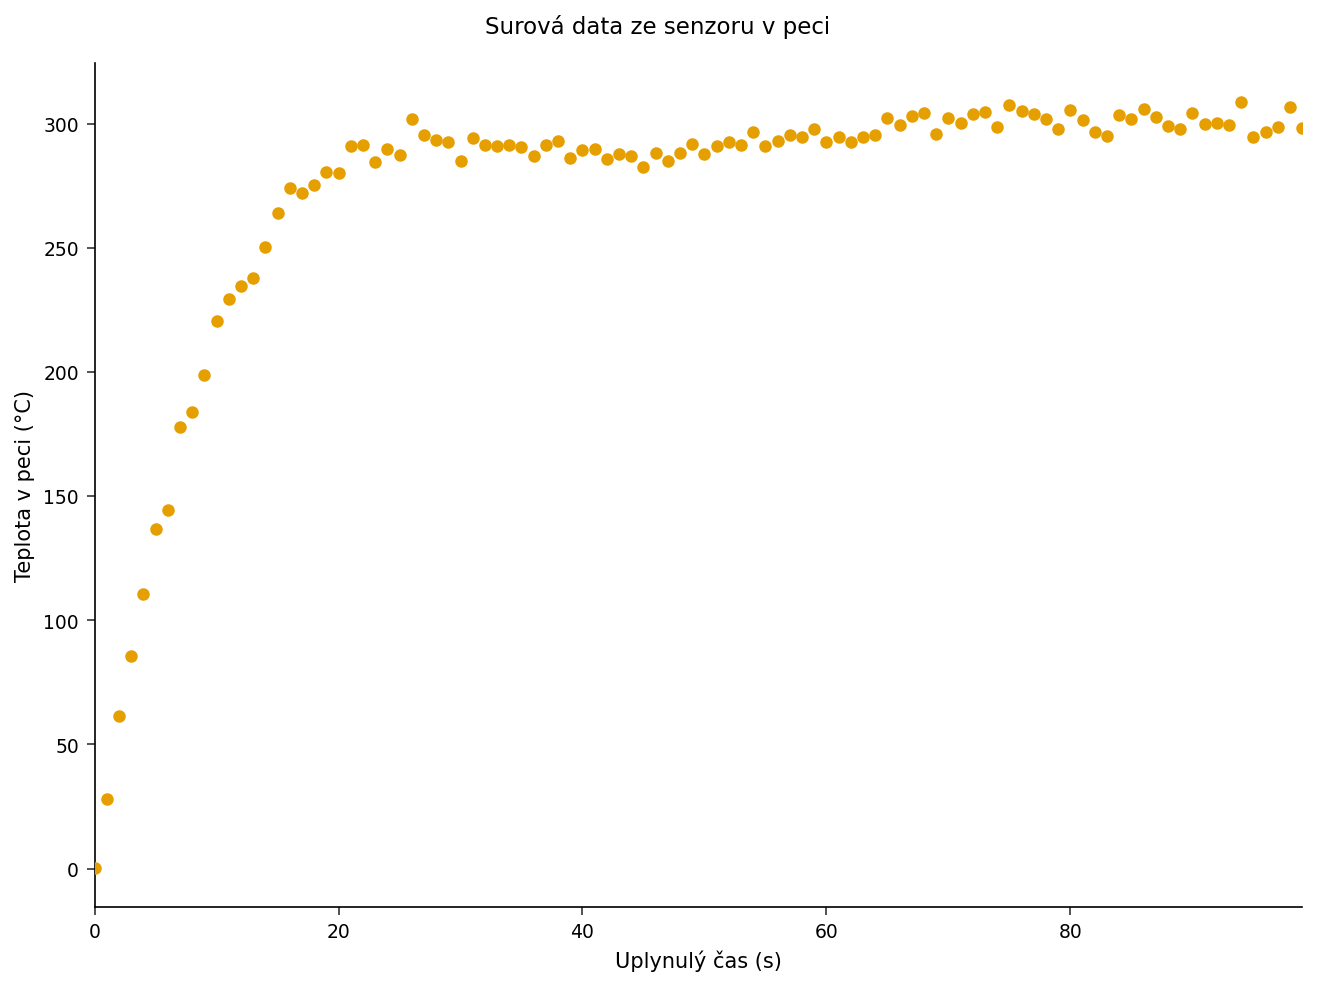

In [2]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT data=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ŠTÍTEK='Uplynulý čas (s)';
    YAXIS ŠTÍTEK='Teplota v peci (°C)';
    NÁZEV 'Surová data ze senzoru v peci';
SPUSTIT;

ODS GRAPHICS OFF;

## Krok 3 — Proložení LOESS s automatickou volbou šířky pásma

Vyhlazovací parametr řídí, jak široké je každé lokální okolí: příliš malý přeučí šum, příliš velký smaže překmit. Místo hádání necháme LOESS, aby jej zvolila minimalizací **opraveného Akaikeho informačního kritéria** pomocí `select=AICC`. Používáme lokální kvadratické polynomy (`degree=2`), aby křivka mohla sledovat zakřivení náběhu a překmitu, a požadujeme 95% interval spolehlivosti pomocí `clm` a `alpha=0.05`.

`ODS OUTPUT` zachytává dvě tabulky jako datové sady: `OutputStatistics` (vyhlazené hodnoty a rezidua pro každý bod) a `FitSummary` (zvolená šířka pásma a diagnostika proložení). Příkaz `OUTPUT` zapisuje datovou sadu `fitted` s predikcí, reziduem a 95% mezemi spolehlivosti pro každé pozorování — surový materiál pro následující grafy.

In [3]:
PROCEDURA loess data=sensor;
    ODS VÝSTUP OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODEL TEMP = t / DEGREE=2 VYBRAT=AICC CLM ALPHA=0.05 details;
    VÝSTUP out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
SPUSTIT;

                                                Prvních 8 vzorků senzoru                                                


                                                  The LOESS Procedure

Dependent Variable: Teplota (°C)
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Krok 4 — Kontrola zvoleného modelu

Souhrn proložení (Fit Summary) zaznamenává AICC-optimální vyhlazovací parametr a stopu predikční matice (efektivní počet stupňů volnosti — míru složitosti modelu). Menší vyhlazovací parametr a větší DF znamenají vlnitější proložení; AICC automaticky vyvažuje shodu s daty proti složitosti.

In [4]:
PROCEDURA TISK data=fit_summary noobs ŠTÍTEK;
    NÁZEV 'Souhrn proložení LOESS (šířka pásma zvolená pomocí AICC)';
SPUSTIT;

                                Souhrn proložení LOESS (šířka pásma zvolená pomocí AICC)                                

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Krok 5 — Překrytí proložení a intervalu spolehlivosti se skutečnou hodnotou

Protože se jedná o simulovaná data, ponechali jsme si bezšumový sloupec `truth`. Vykreslení odhadu LOESS a jeho 95% pásma spolu s `truth` ukazuje, jak věrně vyhlazovač obnovil latentní signál, který nikdy přímo neviděl.

                                Souhrn proložení LOESS (šířka pásma zvolená pomocí AICC)                                




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


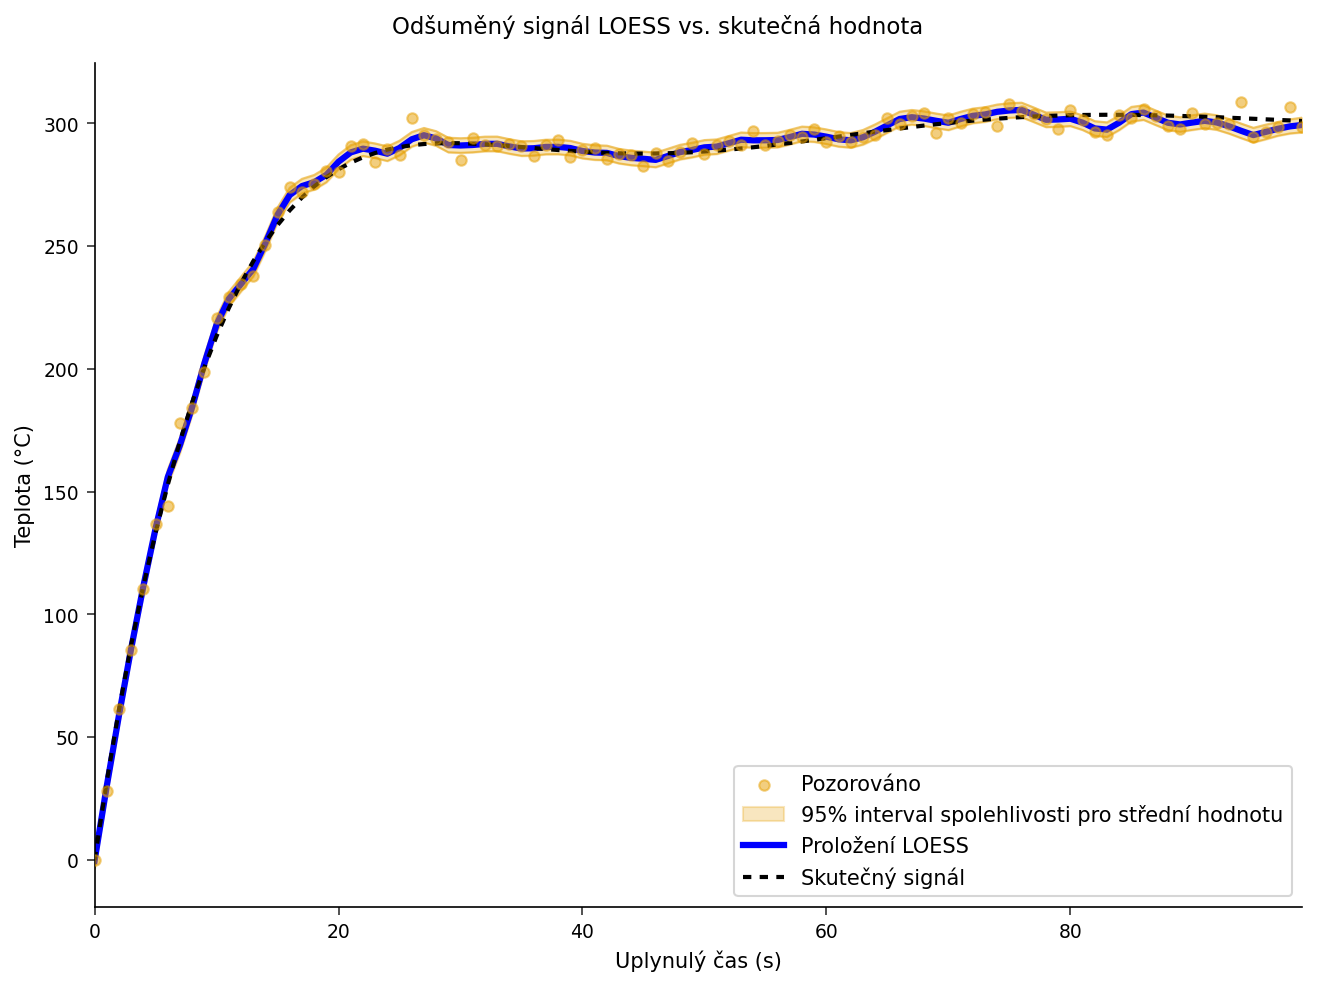

In [5]:
PROCEDURA ŘADIT data=fitted; PODLE t; SPUSTIT;

ODS GRAPHICS ON;

PROCEDURA SGPLOT data=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Pozorováno';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95% interval spolehlivosti pro střední hodnotu';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='Proložení LOESS';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Skutečný signál';
    XAXIS ŠTÍTEK='Uplynulý čas (s)';
    YAXIS ŠTÍTEK='Teplota (°C)';
    NÁZEV 'Odšuměný signál LOESS vs. skutečná hodnota';
SPUSTIT;

ODS GRAPHICS OFF;

## Krok 6 — Diagnostika reziduí

Rezidua (pozorováno mínus proloženo) by měla vypadat jako nestrukturovaný šum se středem na nule. Jakýkoli zbylý trend by signalizoval nedostatečné vyhlazení nebo chybějící rys. Vykreslíme rezidua v čase a shrneme jejich rozptyl — směrodatná odchylka reziduí vychází na 3,10 °C, což je o něco méně než 4 °C šumu, který jsme vnesli, protože lokální proložení pohltí malou část z něj.

                                Souhrn proložení LOESS (šířka pásma zvolená pomocí AICC)                                

                                          Souhrn reziduí (obnovený měřicí šum)                                          

                                                  The MEANS Procedure

 Variable  Label                  N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------
 RESID     Reziduum (°C)        100       0.139       3.096     -11.688      11.909
 ----------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


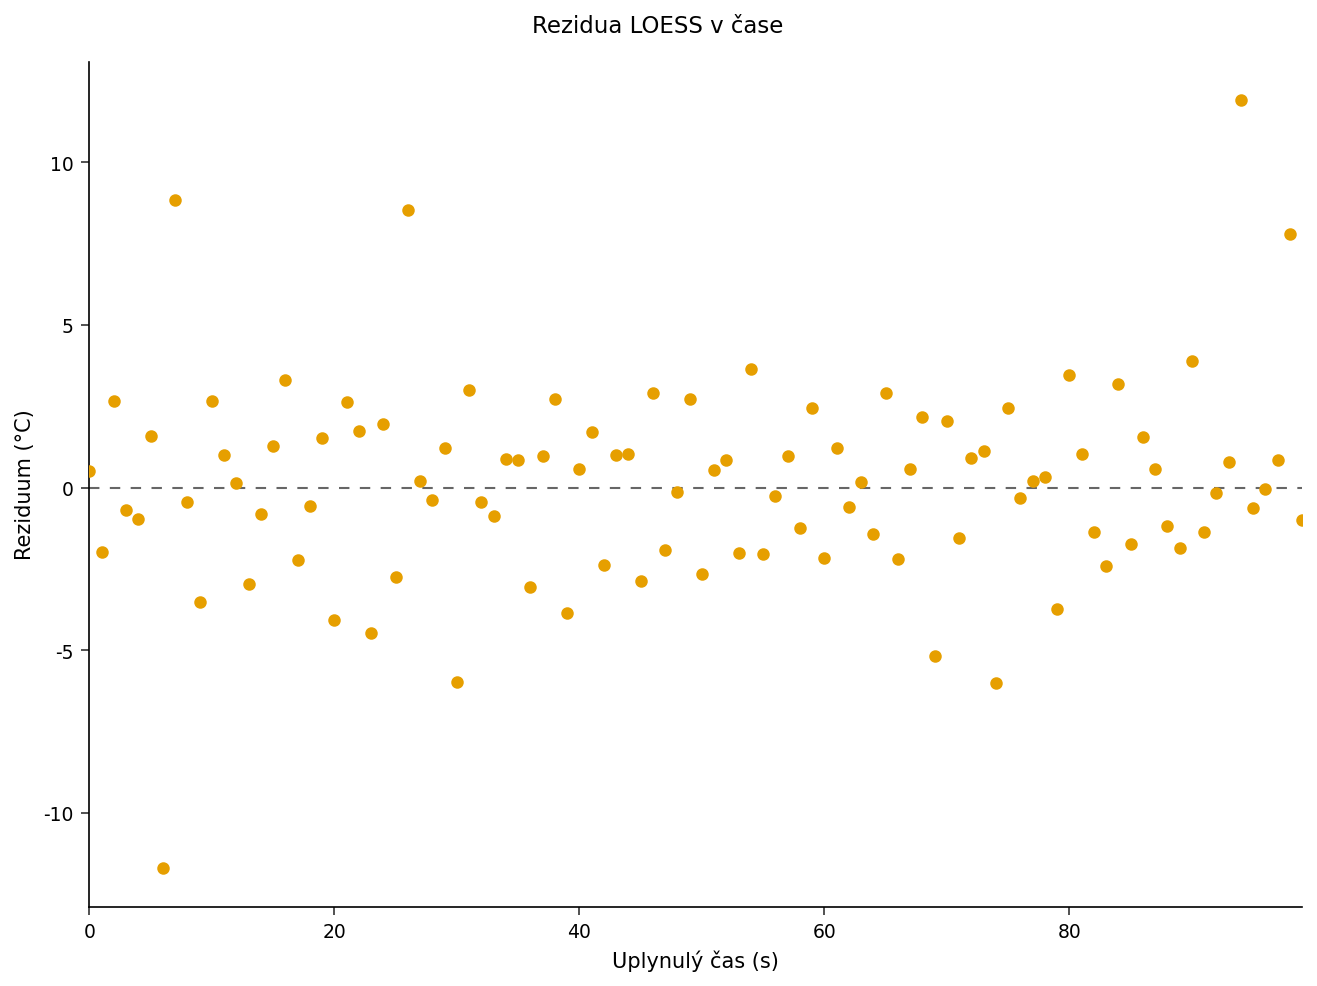

In [6]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT data=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ŠTÍTEK='Uplynulý čas (s)';
    YAXIS ŠTÍTEK='Reziduum (°C)';
    NÁZEV 'Rezidua LOESS v čase';
SPUSTIT;

ODS GRAPHICS OFF;

PROCEDURA PRŮMĚRY data=fitted n mean std MIN MAX maxdec=3;
    PROMĚNNÁ resid;
    ŠTÍTEK resid="Reziduum (°C)";
    NÁZEV 'Souhrn reziduí (obnovený měřicí šum)';
SPUSTIT;

## Krok 7 — Ohodnocení pravidelné monitorovací mřížky pro SPC

Časové značky senzoru nemusí být rovnoměrně rozložené, ale regulační graf vyžaduje signál v pevném taktu. Sestrojíme rovnoměrnou 60bodovou časovou mřížku a aplikujeme na ni proložený model LOESS pomocí příkazu `SCORE`, s požadavkem na meze spolehlivosti. Ohodnocené hodnoty jsou čistý, rovnoměrně rozložený signál připravený k napájení SPC rutiny.

In [7]:
data grid;
    OPAKUJ t = 0 TO 99 PODLE 99/59;
        VÝSTUP;
    KONEC;
SPUSTIT;

PROCEDURA loess data=sensor;
    MODEL TEMP = t / DEGREE=2 VYBRAT=AICC CLM ALPHA=0.05;
    SCORE data=grid CLM TISK;
    NÁZEV 'LOESS ohodnocena na rovnoměrné monitorovací mřížce';
SPUSTIT;

                                          Souhrn reziduí (obnovený měřicí šum)                                          


                                                  The LOESS Procedure

Dependent Variable: Teplota (°C)
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Krok 8 — Kvantifikace odšumění

Nakonec porovnáme surový signál a odhad LOESS se známou skutečnou hodnotou. Střední kvadratická chyba vyhlazeného signálu by měla být mnohem menší než u surových měření, což potvrzuje, že LOESS odstranila měřicí šum a přitom zachovala náběhovou rampu i překmit.

In [8]:
data accuracy;
    NASTAVIT fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
SPUSTIT;

PROCEDURA PRŮMĚRY data=accuracy mean maxdec=3;
    PROMĚNNÁ raw_sq_err loess_sq_err;
    ŠTÍTEK raw_sq_err   = "Střední kvadratická chyba surových dat vůči skutečné hodnotě"
          loess_sq_err = "Střední kvadratická chyba proložení LOESS vůči skutečné hodnotě";
    NÁZEV 'Výkon odšumění: surová data vs. LOESS';
SPUSTIT;

                                         Výkon odšumění: surová data vs. LOESS                                          

                                                  The MEANS Procedure

 Variable      Label                                                                               Mean
 ------------------------------------------------------------------------------------------------------
 raw_sq_err    Střední kvadratická chyba surových dat vůči skutečné hodnotě                      14.774
 loess_sq_err  Střední kvadratická chyba proložení LOESS vůči skutečné hodnotě                    6.629
 ------------------------------------------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretace výsledků

- **Automatická šířka pásma.** `select=AICC` zvolilo vyhlazovací parametr **0,08** bez ručního ladění, což implikuje přibližně **8 ekvivalentních parametrů** — dostatek lokální flexibility na sledování náběhu, překmitu a poklesu a zároveň vyhlazení šumu.
- **Věrné obnovení.** Proložená křivka věrně sleduje latentní signál `truth` napříč rampou, vrcholem překmitu kolem t = 28 i ustalujícím se koncem, což ukazuje, že LOESS obnovila libovolný nelineární signál bez jakýchkoli parametrických předpokladů.
- **Čistá rezidua.** Rezidua se rozptylují kolem nuly se směrodatnou odchylkou **3,10 °C** (průměr 0,14, rozsah −11,7 až 11,9) a nevykazují žádný zbylý časový trend — důkaz, že model není ani přeučený, ani nedostatečně vyhlazený.
- **Měřitelné odšumění.** Oproti skutečné hodnotě odhad LOESS snižuje střední kvadratickou chybu ze **14,77** (surová data) na **6,63** — snížení o 55 %, což je hlavní přínos pro monitorování procesu.
- **Výstup připravený pro SPC.** Krok SCORE dodal odšuměný signál na rovnoměrné 60bodové mřížce s mezemi spolehlivosti, přesně ve formě, kterou navazující regulační graf potřebuje.

**Závěr:** Když senzor procesu produkuje hladký, ale zašuměný signál neznámého tvaru, je PROC LOESS nízkopředpokladovým, samoladicím způsobem, jak extrahovat podkladový trend, připojit meze nejistoty a převzorkovat jej na monitorovací mřížku — to vše bez závazku k parametrickému modelu, který fyzika nemusí ospravedlnit.